Exercise 3: Clustering

GitHub link: https://github.com/LanaElm/Last

1. Function to create synthetic data - please do not change

In [2]:
import numpy as np
from sklearn.datasets import make_blobs, make_moons
import matplotlib.pyplot as plt


def create_data(the_noise, n1_samples, n2_samples, n3_samples, n4_samples):
  # 1
  X_1, y_1 = make_blobs(
    n_samples=n1_samples,
    centers=4,
    random_state=42)

  # 2
  X_2, y_2 = make_moons(
      n_samples=n2_samples,
      noise=the_noise,
      random_state=42
  )

  X_2[:, 0] += 10
  X_2[:, 1] += 10

  # 3
  rng = np.random.RandomState(42)
  angles = rng.rand(n3_samples) * 2 * np.pi
  r = 5.0 + rng.randn(n3_samples) * the_noise
  X_3 = np.column_stack((r * np.cos(angles), r * np.sin(angles)))
  X_3[:, 0] += 20


  # combine
  X = np.vstack((X_1, X_2, X_3))


  return X

2. Call create_data and visualize the data

In [3]:

X = create_data(1.0, 1000, 50, 300, 200)

# Data visuazliation is here:

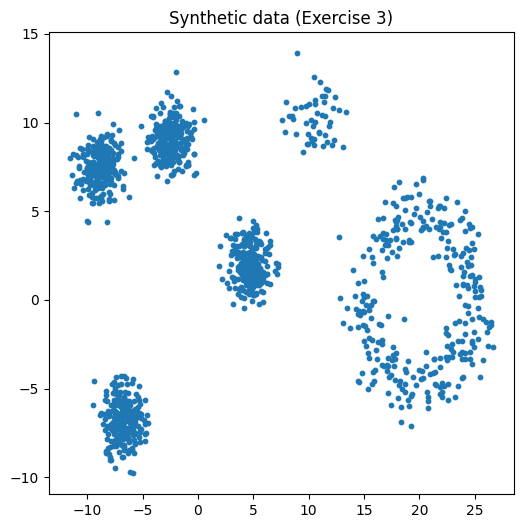

In [4]:
plt.figure(figsize=(6,6))
plt.scatter(X[:,0], X[:,1], s=10)
plt.title("Synthetic data (Exercise 3)")
plt.show()


In [5]:
!pip -q install mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 42.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 96.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 72.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 796.9/796.9 kB 46.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 4.9 MB/s eta 0:00:00


In [6]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

import mlflow

# Scale data (helps clustering)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# MLflow setup
mlflow.set_experiment("ex3_clustering_Lana_Elmaraane")

results = []

def compute_metrics(X_used, labels):
    unique = np.unique(labels)
    if len(unique) < 2:
        return None, None, None
    sil = float(silhouette_score(X_used, labels))
    dbi = float(davies_bouldin_score(X_used, labels))
    ch  = float(calinski_harabasz_score(X_used, labels))
    return sil, dbi, ch


2026/02/09 21:28:20 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.schemas
2026/02/09 21:28:20 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.tables
2026/02/09 21:28:20 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.types
2026/02/09 21:28:20 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.constraints
2026/02/09 21:28:20 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.defaults
2026/02/09 21:28:20 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.comments
2026/02/09 21:28:20 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/02/09 21:28:20 INFO mlflow.store.db.utils: Updating database tables
2026/02/09 21:28:21 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2026/02/09 21:28:21 INFO alembic.runtime.migration: Will assume non-transactional DDL.
2026/02/09 21:28:21 INFO alembic.runtime.migration: Running upgrade  -> 451aebb31d03, add metric step
2026/02/09 21:2

3. Train KMeans
- use library sklearn.cluster.KMeans
- training data: X
- explore and optimize KMeans options
- choose the number of clusters using the Silhouette Method    

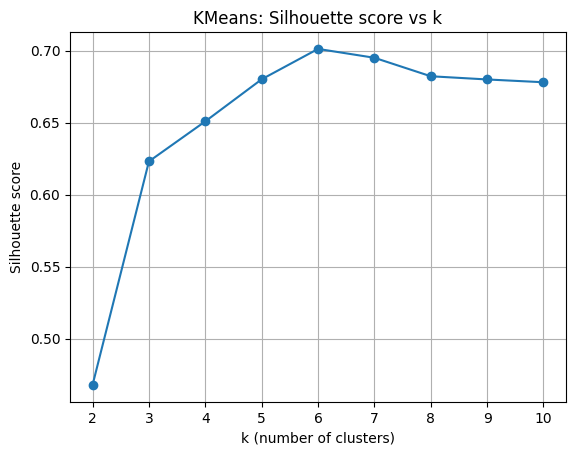

Best k by silhouette: 6


In [7]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

k_values = list(range(2, 11))  # 2..10
sil_scores = []

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_scaled)
    sil, dbi, ch = compute_metrics(X_scaled, labels)
    sil_scores.append(sil)

    with mlflow.start_run(run_name=f"KMeans_k={k}"):
        mlflow.log_param("method", "KMeans")
        mlflow.log_param("k", k)
        mlflow.log_metric("silhouette", sil)
        mlflow.log_metric("davies_bouldin", dbi)
        mlflow.log_metric("calinski_harabasz", ch)

    results.append({
        "method": "KMeans",
        "params": f"k={k}",
        "n_clusters": len(np.unique(labels)),
        "silhouette": sil,
        "davies_bouldin": dbi,
        "calinski_harabasz": ch
    })

# Silhouette plot (to "choose number of clusters using Silhouette Method")
plt.figure()
plt.plot(k_values, sil_scores, marker="o")
plt.title("KMeans: Silhouette score vs k")
plt.xlabel("k (number of clusters)")
plt.ylabel("Silhouette score")
plt.grid(True)
plt.show()

best_k = k_values[int(np.argmax(sil_scores))]
print("Best k by silhouette:", best_k)


4. Train Agglomerative Clustering

- use library sklearn.cluster.AgglomerativeClustering
- training data: X
- explore and optimize AgglomerativeClustering options
- choose the number of clusters using any method you want  

In [8]:
from sklearn.cluster import AgglomerativeClustering

configs = [
    {"n_clusters": 3, "linkage": "ward"},
    {"n_clusters": 4, "linkage": "ward"},
    {"n_clusters": 5, "linkage": "ward"},
    {"n_clusters": 6, "linkage": "ward"},
    {"n_clusters": 4, "linkage": "complete"},
    {"n_clusters": 4, "linkage": "average"},
]

for cfg in configs:
    n_clusters = cfg["n_clusters"]
    linkage = cfg["linkage"]

    model = AgglomerativeClustering(n_clusters=n_clusters, linkage=linkage)
    labels = model.fit_predict(X_scaled)

    sil, dbi, ch = compute_metrics(X_scaled, labels)

    with mlflow.start_run(run_name=f"Agglo_{linkage}_k={n_clusters}"):
        mlflow.log_param("method", "Agglomerative")
        mlflow.log_param("n_clusters", n_clusters)
        mlflow.log_param("linkage", linkage)
        mlflow.log_metric("silhouette", sil)
        mlflow.log_metric("davies_bouldin", dbi)
        mlflow.log_metric("calinski_harabasz", ch)

    results.append({
        "method": "Agglomerative",
        "params": f"n_clusters={n_clusters}, linkage={linkage}",
        "n_clusters": len(np.unique(labels)),
        "silhouette": sil,
        "davies_bouldin": dbi,
        "calinski_harabasz": ch
    })

print("Agglomerative runs:", len(configs))


Agglomerative runs: 6


5. Train DBSCAN
- use library sklearn.cluster.DBSCAN
- training data: X
- explore and optimize DBSCAN options


In [9]:
from sklearn.cluster import DBSCAN

dbscan_configs = [
    {"eps": 0.2, "min_samples": 5},
    {"eps": 0.3, "min_samples": 5},
    {"eps": 0.4, "min_samples": 5},
    {"eps": 0.5, "min_samples": 5},
    {"eps": 0.4, "min_samples": 10},
]

for cfg in dbscan_configs:
    eps = cfg["eps"]
    min_samples = cfg["min_samples"]

    model = DBSCAN(eps=eps, min_samples=min_samples)
    labels = model.fit_predict(X_scaled)

    # ignore noise for metrics
    mask = labels != -1
    if mask.sum() > 10 and len(np.unique(labels[mask])) > 1:
        sil = float(silhouette_score(X_scaled[mask], labels[mask]))
        dbi = float(davies_bouldin_score(X_scaled[mask], labels[mask]))
        ch  = float(calinski_harabasz_score(X_scaled[mask], labels[mask]))
    else:
        sil, dbi, ch = None, None, None

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_pts = int((labels == -1).sum())

    with mlflow.start_run(run_name=f"DBSCAN_eps={eps}_min={min_samples}"):
        mlflow.log_param("method", "DBSCAN")
        mlflow.log_param("eps", eps)
        mlflow.log_param("min_samples", min_samples)
        mlflow.log_param("n_clusters", n_clusters)
        mlflow.log_param("noise_points", noise_pts)
        if sil is not None: mlflow.log_metric("silhouette", sil)
        if dbi is not None: mlflow.log_metric("davies_bouldin", dbi)
        if ch  is not None: mlflow.log_metric("calinski_harabasz", ch)

    results.append({
        "method": "DBSCAN",
        "params": f"eps={eps}, min_samples={min_samples}",
        "n_clusters": n_clusters,
        "noise_points": noise_pts,
        "silhouette": sil,
        "davies_bouldin": dbi,
        "calinski_harabasz": ch
    })

print("DBSCAN runs:", len(dbscan_configs))


DBSCAN runs: 5


6. Compare the results and choose the best method for the data


In [10]:
df = pd.DataFrame(results)

# Sort: higher silhouette is better, lower DB index is better
df_sorted = df.sort_values(by=["silhouette", "davies_bouldin"], ascending=[False, True], na_position="last")

print("Top 10 runs:")
display(df_sorted.head(10))

best = df_sorted.iloc[0]
print("\n✅ Best run:")
print(best)

# Export to Excel (required)
out_name = "Lana_Elmaraane_ex3_results.xlsx"
df_sorted.to_excel(out_name, index=False)
print(f"\nSaved Excel: {out_name}")


Top 10 runs:


,method,params,n_clusters,silhouette,davies_bouldin,calinski_harabasz,noise_points
4,KMeans,k=6,6,0.701125,0.471331,4750.943549,NaN
5,KMeans,k=7,7,0.694980,0.495132,6236.937941,NaN
12,Agglomerative,"n_clusters=6, linkage=ward",6,0.683184,0.493775,4294.152140,NaN
6,KMeans,k=8,8,0.682148,0.553272,6534.862885,NaN
3,KMeans,k=5,5,0.680034,0.580984,3927.882725,NaN
7,KMeans,k=9,9,0.679926,0.506875,6884.287743,NaN
15,DBSCAN,"eps=0.2, min_samples=5",5,0.679223,0.452198,3597.946168,4.0
16,DBSCAN,"eps=0.3, min_samples=5",5,0.678020,0.453775,3585.694914,0.0
17,DBSCAN,"eps=0.4, min_samples=5",5,0.678020,0.453775,3585.694914,0.0
18,DBSCAN,"eps=0.5, min_samples=5",5,0.678020,0.453775,3585.694914,0.0



✅ Best run:
method                    KMeans
params                       k=6
n_clusters                     6
silhouette              0.701125
davies_bouldin          0.471331
calinski_harabasz    4750.943549
noise_points                 NaN
Name: 4, dtype: object

Saved Excel: Lana_Elmaraane_ex3_results.xlsx
